# PowerPulse: Household Energy Usage Forecast

This notebook builds a clean, time-aware machine learning pipeline for forecasting household electricity usage from the UCI Individual Household Electric Power Consumption dataset.

Target: `Global_active_power` in kilowatts.

## Import Libraries

The pipeline uses pandas for time series preparation, scikit-learn for modeling, and matplotlib/seaborn for explainable visualizations.

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from xgboost import XGBRegressor

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor ,VotingRegressor
from sklearn.linear_model import Lasso,Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


np.set_printoptions(suppress=True, precision=8)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Load Dataset

Missing values are stored as `?`, so they are converted to `NaN` while reading. The source file is semicolon-separated.

In [ ]:
DATA_PATH = "data/household_power_consumption.txt"

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    na_values="?",
    low_memory=False
)



## Exploratory Data Analysis (EDA)

In [ ]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425914 entries, 0 to 425913
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Date                   425914 non-null  object 
 1   Time                   425913 non-null  object 
 2   Global_active_power    421983 non-null  float64
 3   Global_reactive_power  421983 non-null  float64
 4   Voltage                421983 non-null  float64
 5   Global_intensity       421983 non-null  float64
 6   Sub_metering_1         421983 non-null  float64
 7   Sub_metering_2         421983 non-null  float64
 8   Sub_metering_3         421983 non-null  float64
dtypes: float64(7), object(2)
memory usage: 29.2+ MB


In [ ]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [ ]:
df.columns = df.columns.str.strip()
df[df["Global_reactive_power"].isnull()&df["Global_active_power"].isnull()&df["Voltage"].isnull()&df["Global_intensity"].isnull()&df["Sub_metering_1"].isnull()&df["Sub_metering_2"].isnull()&df["Sub_metering_3"].isnull()]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1990185,28/9/2010,19:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990186,28/9/2010,19:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990187,28/9/2010,19:11:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990188,28/9/2010,19:12:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Outliers

Column          : Global_active_power
Lower Whisker   : 0.076
Upper Whisker   : 3.358

Outliers: 94907
0          4.216
1          5.360
2          5.374
3          5.388
4          3.666
           ...  
2074573    3.632
2074574    3.616
2074575    3.632
2074576    3.552
2074577    3.552
Name: Global_active_power, Length: 94907, dtype: float64


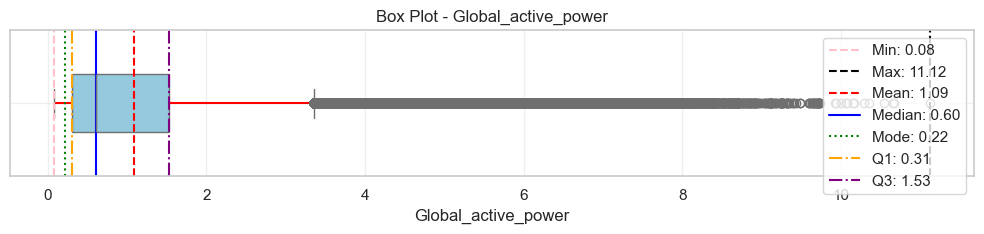

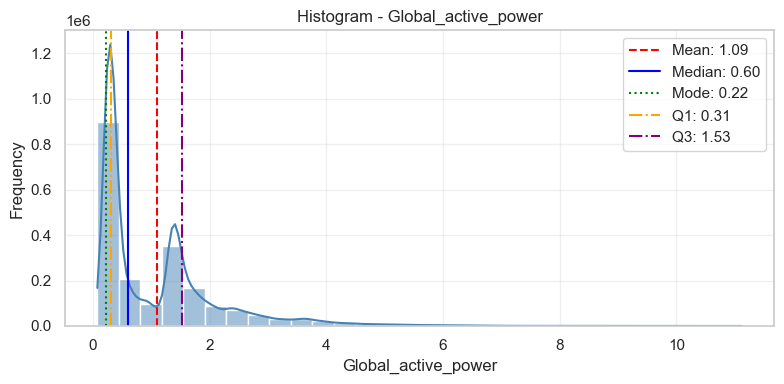

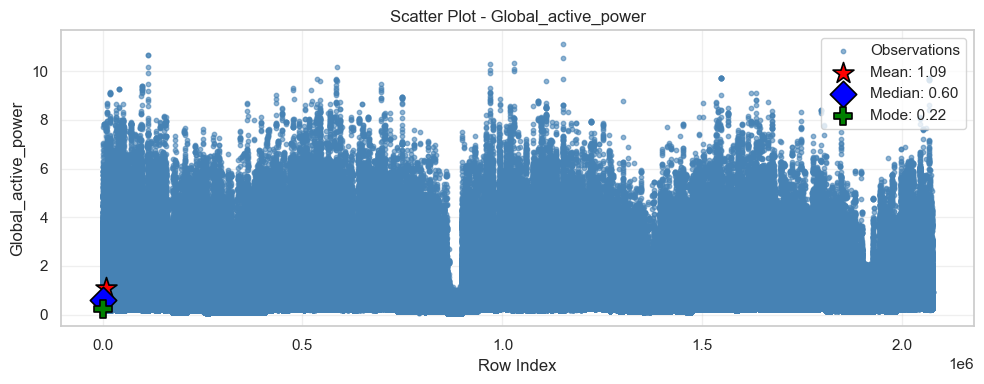

Column          : Global_reactive_power
Lower Whisker   : 0.0
Upper Whisker   : 0.412

Outliers: 40420
0          0.418
1          0.436
2          0.498
3          0.502
4          0.528
           ...  
2074895    0.690
2074896    0.696
2074967    0.428
2074968    0.426
2075006    0.416
Name: Global_reactive_power, Length: 40420, dtype: float64


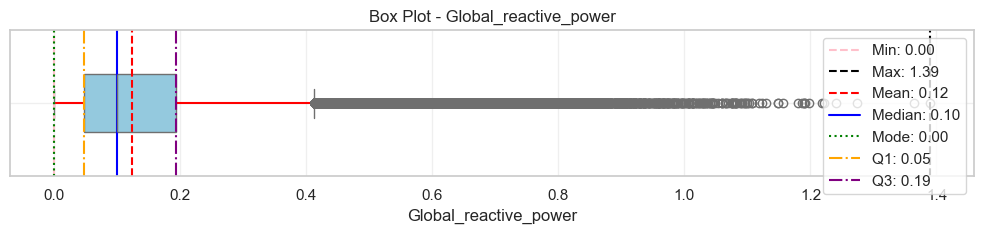

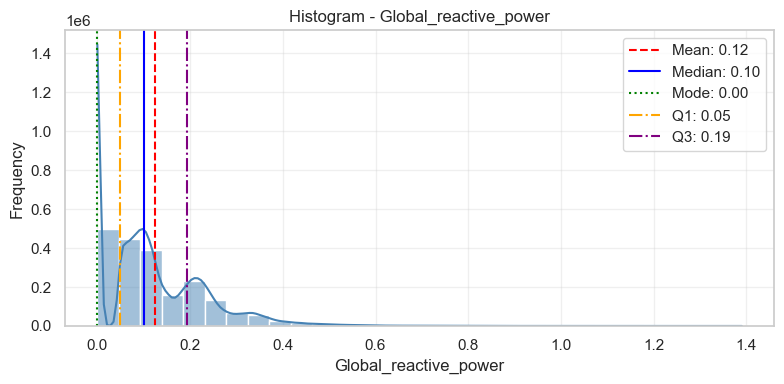

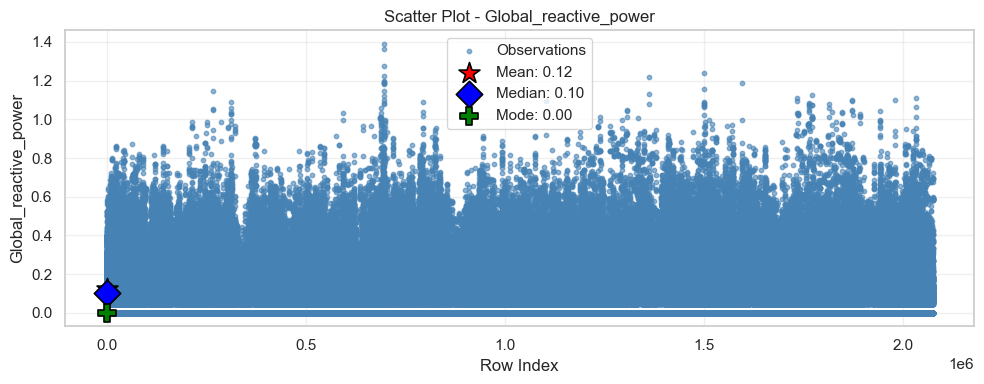

Column          : Voltage
Lower Whisker   : 233.15
Upper Whisker   : 248.73

Outliers: 51067
10         232.86
11         232.78
12         232.99
13         232.91
20         232.69
            ...  
2072414    232.71
2073685    232.96
2073686    232.98
2073689    233.10
2074342    249.01
Name: Voltage, Length: 51067, dtype: float64


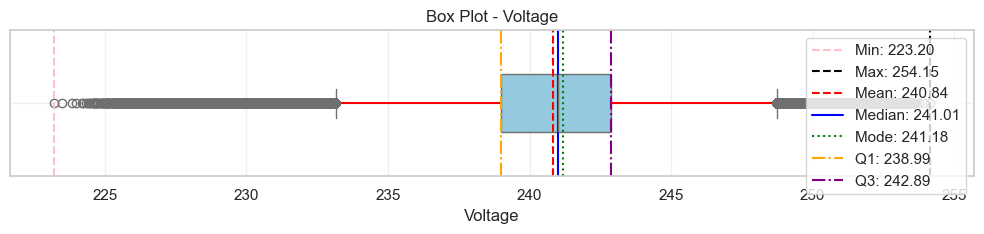

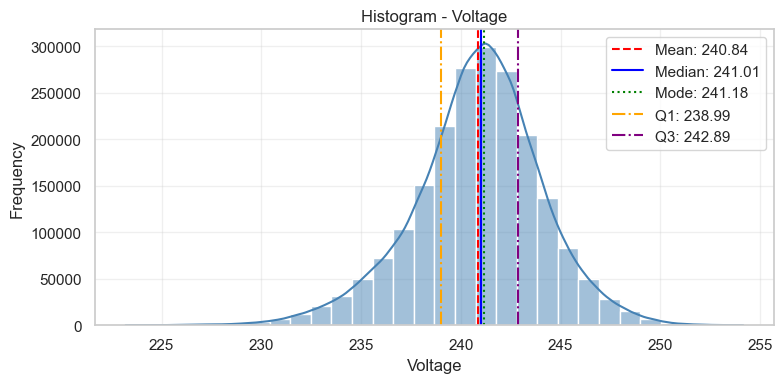

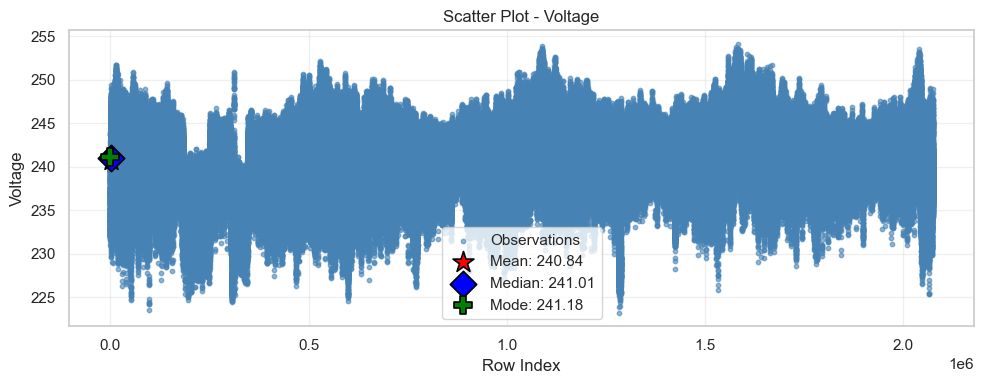

Column          : Global_intensity
Lower Whisker   : 0.2
Upper Whisker   : 13.8

Outliers: 100961
0          18.4
1          23.0
2          23.0
3          23.0
4          15.8
           ... 
2074573    15.0
2074574    15.0
2074575    15.0
2074576    14.8
2074577    14.8
Name: Global_intensity, Length: 100961, dtype: float64


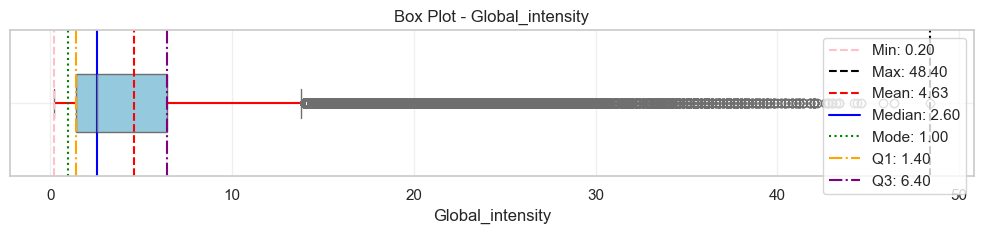

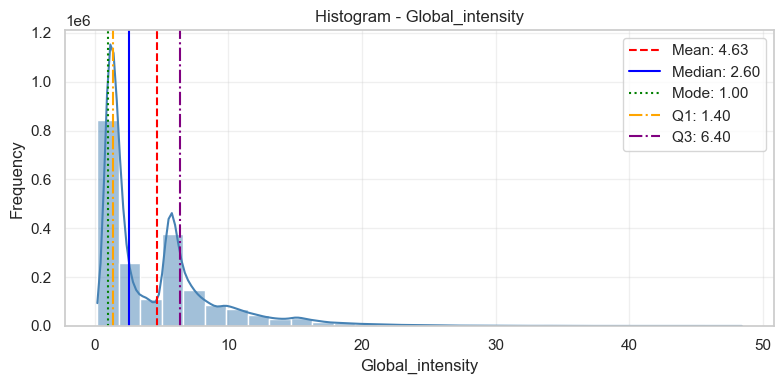

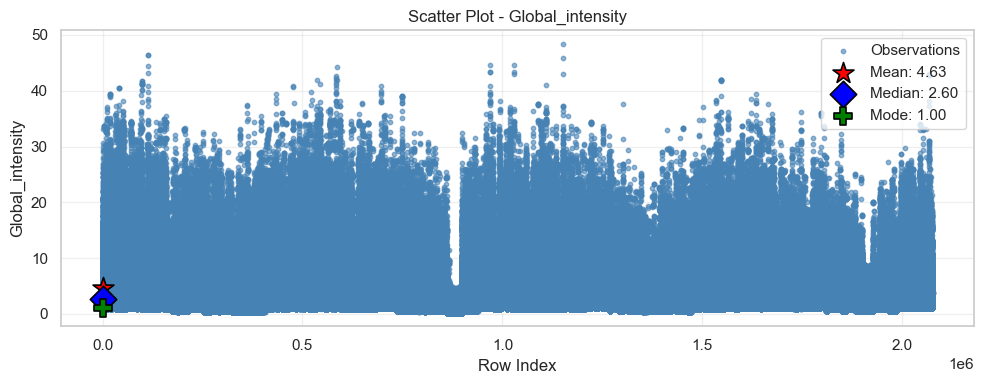

Column          : Sub_metering_1
Lower Whisker   : 0.0
Upper Whisker   : 0.0

Outliers: 169105
1019        1.0
1020        2.0
1021        1.0
1022        1.0
1023        1.0
           ... 
2074575    38.0
2074576    38.0
2074577    38.0
2074578    11.0
2074583     1.0
Name: Sub_metering_1, Length: 169105, dtype: float64


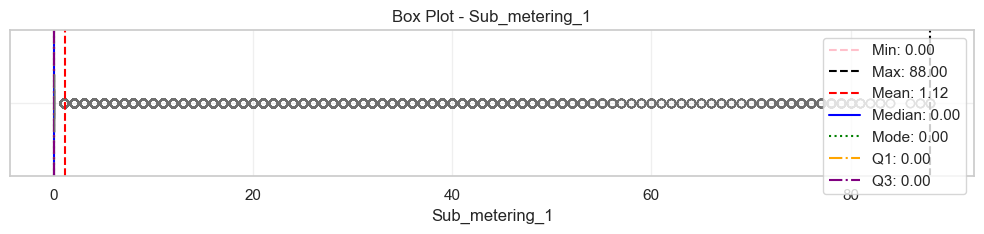

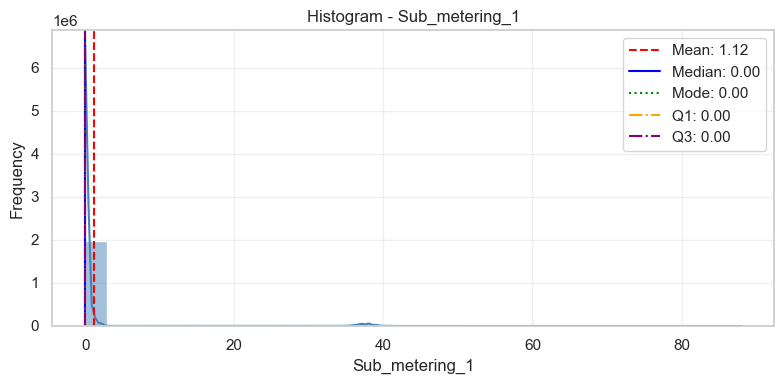

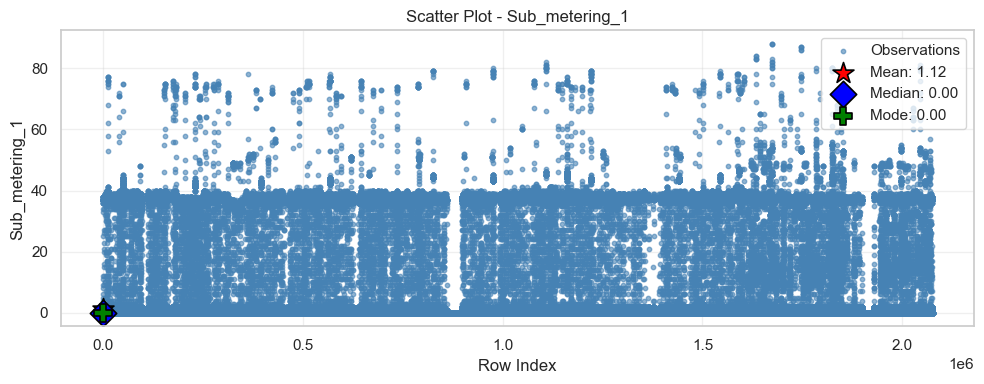

Column          : Sub_metering_2
Lower Whisker   : 0.0
Upper Whisker   : 2.0

Outliers: 77151
39         16.0
40         37.0
41         37.0
42         36.0
43         37.0
           ... 
2072184     4.0
2072185     3.0
2072186     4.0
2072187     3.0
2072188     4.0
Name: Sub_metering_2, Length: 77151, dtype: float64


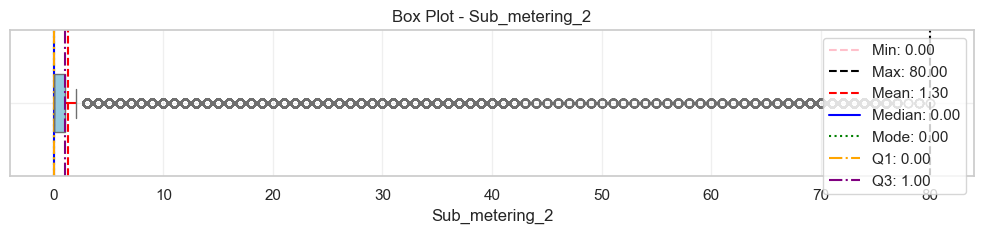

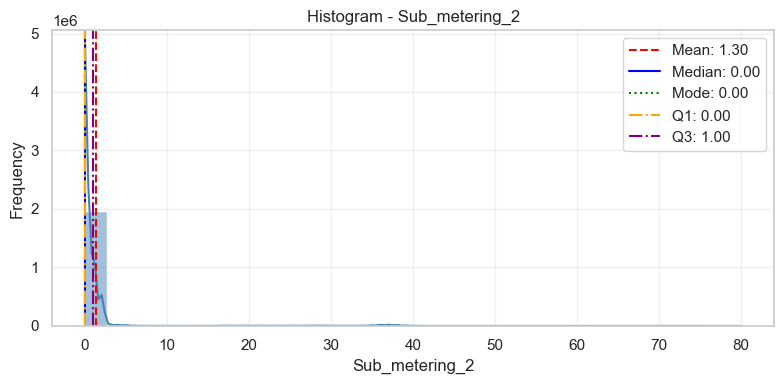

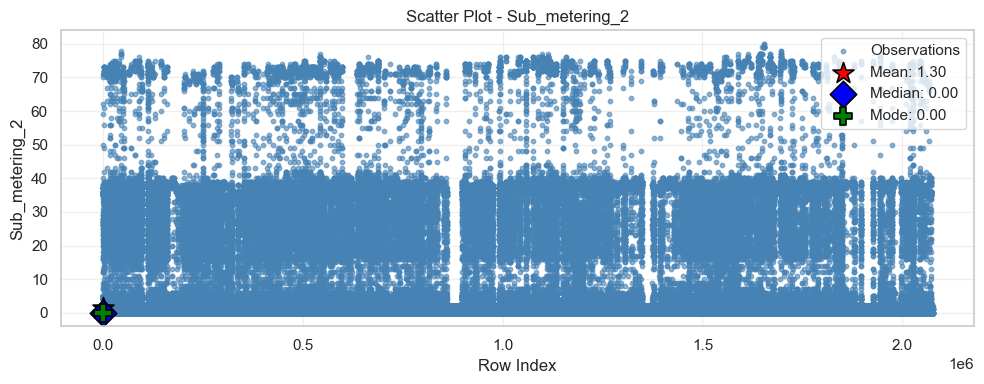

Column          : Sub_metering_3
Lower Whisker   : 0.0
Upper Whisker   : 31.0

Outliers: 0
Series([], Name: Sub_metering_3, dtype: float64)


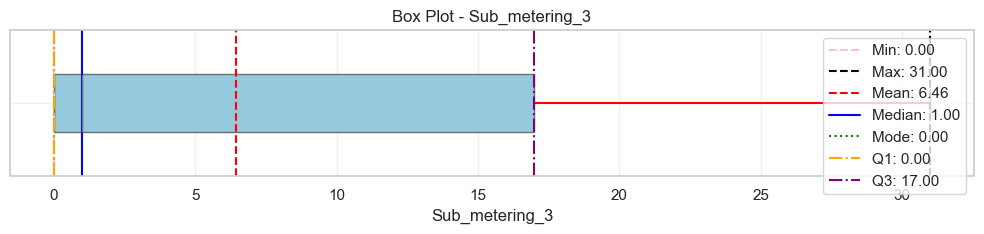

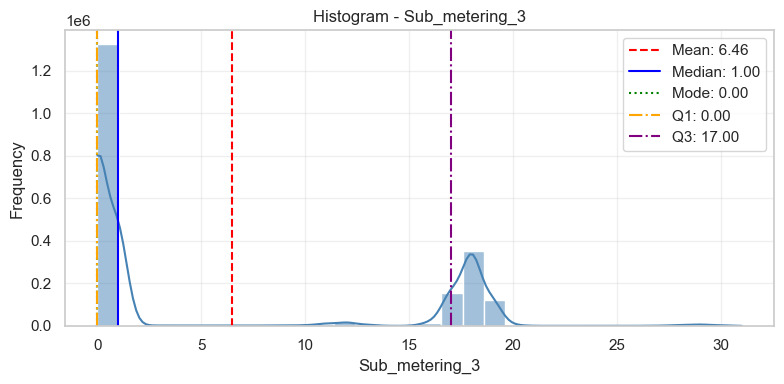

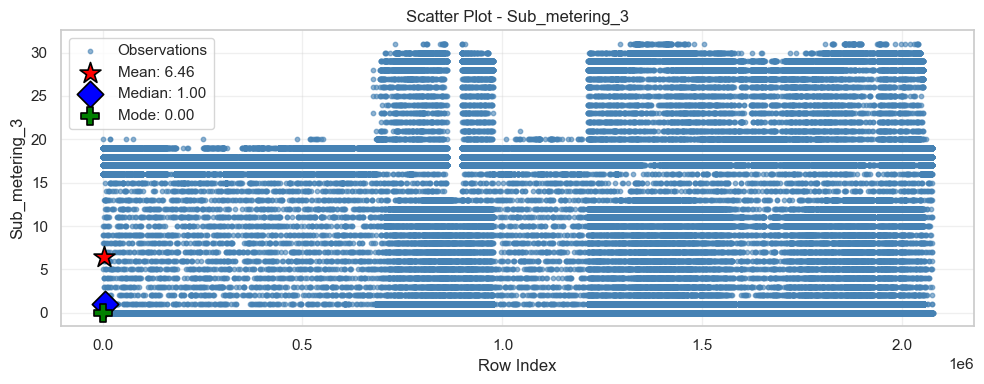

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:

    data = df[col].dropna()

    # =============================
    # Statistics
    # =============================
    mean = data.mean()
    median = data.median()
    mode = data.mode().iloc[0]
    min=data.min()
    max=data.max()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    # Find the actual observation closest to each statistic
    mean_idx = (data - mean).abs().idxmin()
    median_idx = (data - median).abs().idxmin()
    mode_idx = data[data == mode].index[0]
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    # Actual whiskers (same rule used by seaborn)
    lower_whisker = data[data >= lower_limit].min()
    upper_whisker = data[data <= upper_limit].max()

    print(f"Column          : {col}")
    print(f"Lower Whisker   : {lower_whisker}")
    print(f"Upper Whisker   : {upper_whisker}")

    outliers = data[(data < lower_whisker) | (data > upper_whisker)]

    print("\nOutliers: " + str(len(outliers))+"/"+ str(len(data)))
    print(outliers)
    # =============================
    # Box Plot
    # =============================
    plt.figure(figsize=(10, 2.5))

    sns.boxplot(
        x=data,
        color="skyblue",
        width=0.4,whiskerprops=dict(linewidth=1.5, color='red')
    )


    plt.axvline(min,
                color='pink',
                linestyle='--',
                label=f"Min: {min:.2f}")

    plt.axvline(max,
                color='black',
                linestyle='--',
                label=f"Max: {max:.2f}")

    plt.axvline(mean,
                color='red',
                linestyle='--',
                label=f"Mean: {mean:.2f}")

    plt.axvline(median,
                color='blue',
                label=f"Median: {median:.2f}")

    plt.axvline(mode,
                color='green',
                linestyle=':',
                label=f"Mode: {mode:.2f}")

    plt.axvline(q1,
                color='orange',
                linestyle='-.',
                label=f"Q1: {q1:.2f}")

    plt.axvline(q3,
                color='purple',
                linestyle='-.',
                label=f"Q3: {q3:.2f}")

    plt.title(f"Box Plot - {col}")
    plt.xlabel(col)
    plt.grid(alpha=0.3)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    # =============================
    # Histogram
    # =============================
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data,
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.axvline(mean,
                color='red',
                linestyle='--',
                label=f"Mean: {mean:.2f}")

    plt.axvline(median,
                color='blue',
                label=f"Median: {median:.2f}")

    plt.axvline(mode,
                color='green',
                linestyle=':',
                label=f"Mode: {mode:.2f}")

    plt.axvline(q1,
                color='orange',
                linestyle='-.',
                label=f"Q1: {q1:.2f}")

    plt.axvline(q3,
                color='purple',
                linestyle='-.',
                label=f"Q3: {q3:.2f}")

    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # =============================
    # Scatter Plot
    # =============================
    plt.figure(figsize=(10, 4))

    plt.scatter(
        data.index,
        data,
        s=10,
        alpha=0.6,
        color="steelblue",
        label="Observations"
    )

    # Highlight Mean
    plt.scatter(
        mean_idx,
        mean,
        color="red",
        s=250,
        marker="*",
        edgecolors="black",
        linewidth=1.2,
        label=f"Mean: {mean:.2f}"
    )

    # Highlight Median
    plt.scatter(
        median_idx,
        median,
        color="blue",
        s=180,
        marker="D",
        edgecolors="black",
        linewidth=1.2,
        label=f"Median: {median:.2f}"
    )

    # Highlight Mode
    plt.scatter(
        mode_idx,
        mode,
        color="green",
        s=180,
        marker="P",
        edgecolors="black",
        linewidth=1.2,
        label=f"Mode: {mode:.2f}"
    )

    plt.title(f"Scatter Plot - {col}")
    plt.xlabel("Row Index")
    plt.ylabel(col)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

### imputation

### correlations

In [ ]:
df.cov(numeric_only=True)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.117871,0.029440,-1.369431,4.693812,3.151303,2.675029,5.696268
Global_reactive_power,0.029440,0.012706,-0.040994,0.133321,0.085387,0.091373,0.085230
Voltage,-1.369431,-0.040994,10.497514,-5.923540,-3.906917,-3.157804,-7.330823
Global_intensity,4.693812,0.133321,-5.923540,19.752658,13.380598,11.394140,23.494135
Sub_metering_1,3.151303,0.085387,-3.906917,13.380598,37.859792,1.960272,5.324882
Sub_metering_2,2.675029,0.091373,-3.157804,11.394140,1.960272,33.895992,3.972543
Sub_metering_3,5.696268,0.085230,-7.330823,23.494135,5.324882,3.972543,71.185566


In [ ]:
df.corr(numeric_only=True)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000


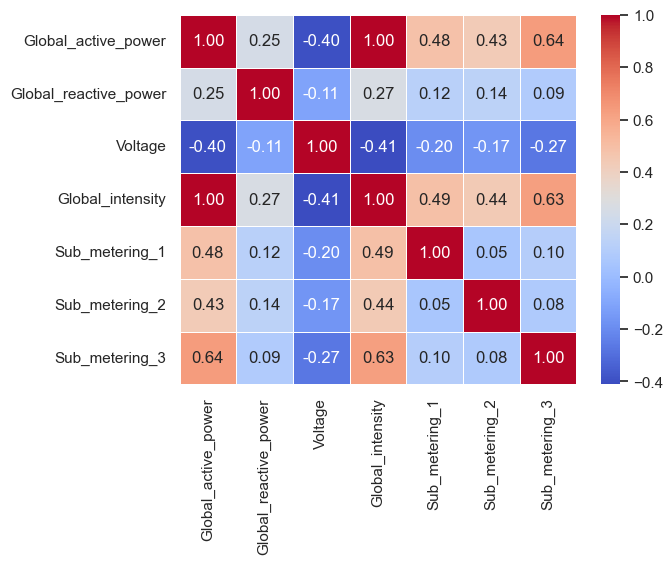

In [ ]:
corr_matrix = df.corr(numeric_only=True).dropna()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [ ]:
# 1. Filter the DataFrame to include only numerical columns
df_numeric = df.select_dtypes(include=[np.number])

# 2. Ensure there are no NaNs or Infs (VIF cannot handle them)
# If your data has missing values, you should handle them first (e.g., fillna or dropna)
df_numeric = df_numeric.dropna()

# 3. Create a DataFrame to hold the VIF values
vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# 4. Calculate VIF
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i) for i in range(df_numeric.shape[1])]
vif_data["Tolerance"] = 1 / vif_data["VIF"]
vif_data

,feature,VIF,Tolerance
0,Global_active_power,1268.568948,0.000788
1,Global_reactive_power,2.885946,0.346507
2,Voltage,3.058344,0.326974
3,Global_intensity,1273.977676,0.000785
4,Sub_metering_1,1.662797,0.601396
5,Sub_metering_2,1.571148,0.636477
6,Sub_metering_3,3.638213,0.274860


In [ ]:

# 1. Filter the DataFrame to include only numerical columns
df_numeric = df.select_dtypes(include=[np.number])

# 2. Ensure there are no NaNs or Infs (VIF cannot handle them)
df_numeric = df_numeric.dropna()

# --- NEW: Correlation Matrix & Heatmap ---
# Calculate the correlation matrix
corr_matrix = df_numeric.corr()


# 3. Create a DataFrame to hold the VIF values
vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# 4. Calculate VIF and Tolerance
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i) for i in range(df_numeric.shape[1])]
vif_data["Tolerance"] = 1 / vif_data["VIF"]
display(vif_data)

# --- NEW: Condition Number / Eigenvalues ---
# Compute eigenvalues of the correlation matrix of the numerical features
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# 2. Create a DataFrame for the eigenvectors with feature names as rows/index
# and component columns corresponding to the eigenvalues
eigenvectors_df = pd.DataFrame(
    eigenvectors,
    index=df_numeric.columns,
    columns=[f"PC_{i+1}" for i in range(len(eigenvalues))]
)
# Compute the condition number of the correlation matrix
# High condition numbers (typically > 30) indicate severe multicollinearity
condition_number = np.linalg.cond(corr_matrix)

print(f"\nCondition Number of the Correlation Matrix: {condition_number}")
print("Eigenvalues of the Correlation Matrix:")
print(eigenvalues)

print("\nEigenvectors (Feature Contributions per Component):")
display(eigenvectors_df)
# Show important features in each PC
for pc in eigenvectors_df.columns:
    print(f"\n{'='*40}")
    print(pc)
    print(eigenvectors_df[pc].abs().sort_values(ascending=False))
    print(f"{'='*40}\n")

,feature,VIF,Tolerance
0,Global_active_power,1268.568948,0.000788
1,Global_reactive_power,2.885946,0.346507
2,Voltage,3.058344,0.326974
3,Global_intensity,1273.977676,0.000785
4,Sub_metering_1,1.662797,0.601396
5,Sub_metering_2,1.571148,0.636477
6,Sub_metering_3,3.638213,0.274860



Condition Number of the Correlation Matrix: 4387.372169193626
Eigenvalues of the Correlation Matrix:
[3.23005565 0.00073622 0.21754778 0.78241121 0.84924843 0.98740318
 0.93259753]

Eigenvectors (Feature Contributions per Component):


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7
Global_active_power,-0.538110,-0.705753,0.426224,0.158681,0.044768,-0.051120,0.029787
Global_reactive_power,-0.186795,-0.013442,-0.078199,-0.026497,-0.626793,0.670378,-0.340342
Voltage,0.296112,0.009883,0.056465,0.939560,0.049393,0.142392,-0.059525
Global_intensity,-0.539818,0.708166,0.429156,0.140694,0.041949,-0.031671,0.019112
Sub_metering_1,-0.295305,-0.002067,-0.405251,0.063086,0.430782,-0.100469,-0.740888
Sub_metering_2,-0.266084,-0.002412,-0.364748,0.026183,0.465114,0.573268,0.500500
Sub_metering_3,-0.372094,0.011237,-0.572351,0.258621,-0.446120,-0.433556,0.282765



PC_1
Global_intensity         0.539818
Global_active_power      0.538110
Sub_metering_3           0.372094
Voltage                  0.296112
Sub_metering_1           0.295305
Sub_metering_2           0.266084
Global_reactive_power    0.186795
Name: PC_1, dtype: float64

PC_2
Global_intensity         0.708166
Global_active_power      0.705753
Global_reactive_power    0.013442
Sub_metering_3           0.011237
Voltage                  0.009883
Sub_metering_2           0.002412
Sub_metering_1           0.002067
Name: PC_2, dtype: float64

PC_3
Sub_metering_3           0.572351
Global_intensity         0.429156
Global_active_power      0.426224
Sub_metering_1           0.405251
Sub_metering_2           0.364748
Global_reactive_power    0.078199
Voltage                  0.056465
Name: PC_3, dtype: float64

PC_4
Voltage                  0.939560
Sub_metering_3           0.258621
Global_active_power      0.158681
Global_intensity         0.140694
Sub_metering_1           0.063086
Global_reac

In [ ]:

# 1. Filter the DataFrame to include only numerical columns
df_numeric = df.select_dtypes(include=[np.number])

# 2. Ensure there are no NaNs or Infs (VIF cannot handle them)
df_numeric = df_numeric.dropna()
df_numeric = df_numeric.drop(['Global_intensity'], axis=1, errors='ignore')

# --- NEW: Correlation Matrix & Heatmap ---
# Calculate the correlation matrix
corr_matrix = df_numeric.corr()


# 3. Create a DataFrame to hold the VIF values
vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# 4. Calculate VIF and Tolerance
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i) for i in range(df_numeric.shape[1])]
vif_data["Tolerance"] = 1 / vif_data["VIF"]
display(vif_data)

# --- NEW: Condition Number / Eigenvalues ---
# Compute eigenvalues of the correlation matrix of the numerical features
eigenvalues, _ = np.linalg.eig(corr_matrix)

# Compute the condition number of the correlation matrix
# High condition numbers (typically > 30) indicate severe multicollinearity
condition_number = np.linalg.cond(corr_matrix)

print("Eigenvalues of the Correlation Matrix:")
print(eigenvalues)
print(f"\nCondition Number of the Correlation Matrix: {condition_number}")

,feature,VIF,Tolerance
0,Global_active_power,7.558893,0.132295
1,Global_reactive_power,2.367952,0.422306
2,Voltage,3.052287,0.327623
3,Sub_metering_1,1.652439,0.605166
4,Sub_metering_2,1.559300,0.641314
5,Sub_metering_3,3.449242,0.289919


Eigenvalues of the Correlation Matrix:
[2.3174058  0.15751665 0.75931453 0.84757965 0.98603979 0.93214358]

Condition Number of the Correlation Matrix: 14.712131980956428


<Axes: xlabel='Global_active_power', ylabel='Global_intensity'>

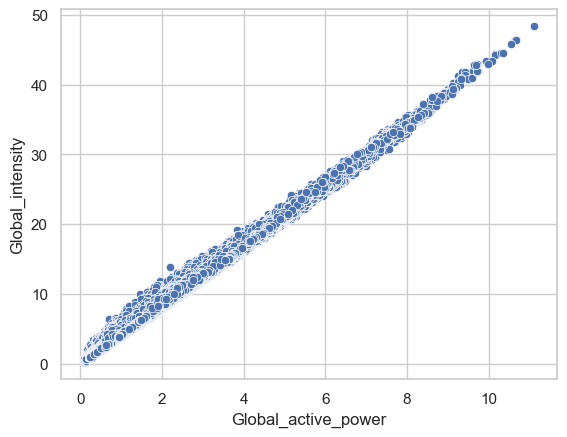

In [ ]:
sns.scatterplot( data= df, x = "Global_active_power", y = 'Global_intensity' )

In [ ]:
df1 = df.copy()
df1['Apparent_power'] = (df1['Voltage']*df1['Global_intensity'])/1000
df1['Sub_metering_others'] = (df1['Global_active_power']*1000/60)-(df1['Sub_metering_1']+df1['Sub_metering_2']+df1['Sub_metering_3'])
df1['Total_sub_metering'] = df1['Sub_metering_1']+df1['Sub_metering_2']+df1['Sub_metering_3'] +df1['Sub_metering_others']
df1['Power_factor'] = df1['Global_active_power'] / df1['Apparent_power']
df1

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Apparent_power,Sub_metering_others,Total_sub_metering,Power_factor
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,4.321056,52.266667,70.266667,0.975687
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,5.373490,72.333333,89.333333,0.997490
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,5.365670,70.566667,89.566667,1.001552
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,5.376020,71.800000,89.800000,1.002228
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,3.723744,43.100000,61.100000,0.984493
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0,0.961720,15.766667,15.766667,0.983654
2075255,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0,0.960000,15.733333,15.733333,0.983333
2075256,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0,0.911316,15.633333,15.633333,1.029281
2075257,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0,0.910860,15.566667,15.566667,1.025405


##  Data Preprocessing

In [ ]:
# Combine Date and Time into one timestamp column.
# dayfirst=True is required because the dataset stores dates as dd/mm/yyyy.
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

# Convert all measurement columns to numeric values.
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Set datetime as the index, sort chronologically, and remove invalid rows.
df = (
    df.drop(columns=["Date", "Time"])
      .dropna(subset=["datetime"])
      .set_index("datetime")
      .sort_index()
)

print(df.isna().sum())

Global_active_power      3930
Global_reactive_power    3930
Voltage                  3930
Global_intensity         3930
Sub_metering_1           3930
Sub_metering_2           3930
Sub_metering_3           3930
dtype: int64


In [ ]:
# Drop rows with missing measurements.
# For this dataset the missing rows are a small fraction of the full minute-level history.
clean_df = df.dropna().copy()

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(clean_df):,}")
print(f"Removed rows:         {len(df) - len(clean_df):,}")
clean_df.head()

Rows before cleaning: 425,913
Rows after cleaning:  421,983
Removed rows:         3,930


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Feature Engineering

In [ ]:
features_df = clean_df.copy()

# Calendar features
features_df["hour"] = features_df.index.hour
features_df["month"] = features_df.index.month
features_df["day_of_week"] = features_df.index.dayofweek
features_df["peak_hour"] = features_df["hour"].between(18, 22).astype(int)
features_df["is_weekend"] = (features_df["day_of_week"] >= 5).astype(int)

# Lagged rolling mean of the target.
# shift(1) prevents the current target value from leaking into its own prediction.
features_df["rolling_mean"] = (
    features_df["Global_active_power"]
    .shift(1)
    .rolling(window=5, min_periods=5)
    .mean()
)


features_df = features_df.dropna().copy()
features_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,month,day_of_week,peak_hour,is_weekend,rolling_mean,other_energy
datetime,,,,,,,,,,,,,,
2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0,17,12,5,0,1,4.8008,39.666667
2006-12-16 17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0,17,12,5,0,1,4.6616,43.700000
2006-12-16 17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0,17,12,5,0,1,4.3300,43.666667
2006-12-16 17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0,17,12,5,0,1,3.9952,43.133333
2006-12-16 17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0,17,12,5,0,1,3.6512,43.033333


## 5. Exploratory Visualizations

In [ ]:
plt.figure(figsize=(10, 5))
hourly_power = features_df.groupby("hour")["Global_active_power"].mean()
sns.lineplot(x=hourly_power.index, y=hourly_power.values, marker="o")
plt.title("Average Power Usage by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(range(0, 24))
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=features_df,
    x="peak_hour",
    y="Global_active_power",
    estimator="mean",
    errorbar=None
)
plt.title("Peak vs Non-Peak Usage")
plt.xlabel("Period")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks([0, 1], ["Non-Peak", "Peak"])
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))
corr_cols = [
    "Global_active_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour",
    "month",
    "day_of_week",
    "rolling_mean",
]
sns.heatmap(features_df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

## 6. Time-Based Train/Test Split

In [ ]:
target_col = "Global_active_power"

feature_cols = [
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour",
    "month",
    "day_of_week",
    "peak_hour",
    "is_weekend",
    "rolling_mean",
]

X = features_df[feature_cols]
y = features_df[target_col]

# Chronological split: first 80% for training, last 20% for testing.
split_idx = int(len(features_df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train period: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test period:  {X_test.index.min()} to {X_test.index.max()}")
print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")

Train period: 2006-12-16 17:29:00 to 2007-08-10 21:17:00
Test period:  2007-08-10 21:18:00 to 2007-10-08 11:56:00
Train rows: 337,582 | Test rows: 84,396


Total Data Points available for Cross-Validation: 2049275


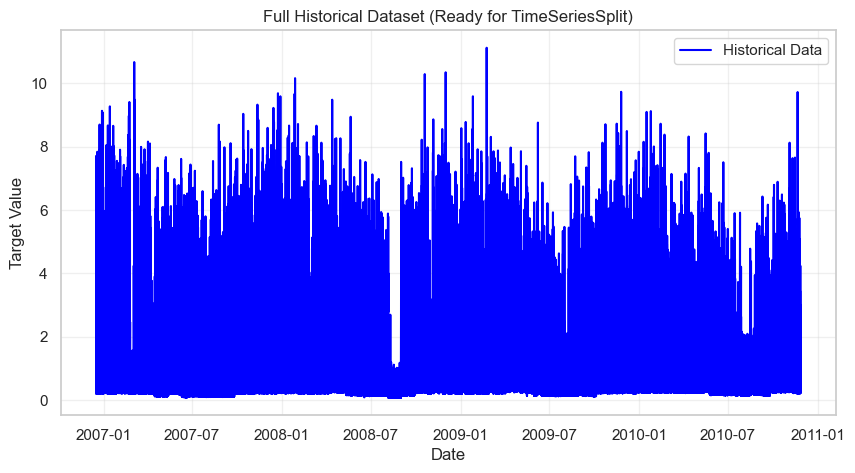

In [ ]:
print(f"Total Data Points available for Cross-Validation: {len(dff[feature_cols])}")

# Optional: Visualize the full timeline to see the trend
plt.figure(figsize=(10, 5))
plt.plot(dff.index, dff['Global_active_power'], label='Historical Data', color='blue')
plt.title('Full Historical Dataset (Ready for TimeSeriesSplit)')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Model Training and Hyperparameter Tuning (Randomiz Search)

In [ ]:


def evaluate_model(name, model, X_test, y_test):
    # Return common regression metrics for one fitted model.
    preds = model.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    }


# Tune on the most recent training rows to keep the notebook practical on the full minute-level dataset.
tuning_size = min(200_000, len(X_train))
X_tune = X_train.iloc[-tuning_size:]
y_tune = y_train.iloc[-tuning_size:]


tscv = TimeSeriesSplit(n_splits=5)

models = {

        "Ridge": {
        "estimator": Pipeline([
            ("scaler", RobustScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        },
    },

    "Lasso": {
        "estimator": Pipeline([
            ("scaler", RobustScaler()),
            ("model", Lasso(max_iter=10000))
        ]),
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10]
        },
    },
    "Random Forest": {
        "estimator": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        },
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "subsample": [0.8, 1.0],
        },
    },
    "XGBoost": {
    "estimator": XGBRegressor(
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        n_jobs=-1,
    tree_method="hist"
    ),
    "params": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 5, 7],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],

        # Regularization
        "reg_alpha": [0, 0.01, 0.1, 1],    # L1
        "reg_lambda": [1, 5, 10, 20],       # L2
        },
    },
}

fitted_models = {}
results = []

for name, config in models.items():
    print(f"Training {name}...")
    estimator = config["estimator"]
    params = config["params"]

    if params:
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=6,
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=0,
        )
        search.fit(X_tune, y_tune)
        best_model = search.best_estimator_
        print(f"Best parameters: {search.best_params_}")
    else:
        best_model = estimator.fit(X_tune, y_tune)

    # Refit the selected configuration on the full training period.
    best_model.fit(X_train, y_train)
    fitted_models[name] = best_model
    results.append(evaluate_model(name, best_model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

Training Ridge...
Best parameters: {'model__alpha': 10}
Training Lasso...
Best parameters: {'model__alpha': 0.001}
Training Random Forest...
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
Training Gradient Boosting...
Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Training XGBoost...
Best parameters: {'subsample': 0.8, 'reg_lambda': 20, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


,model,MAE,RMSE,R2
4,XGBoost,0.019106,0.030304,0.999135
3,Gradient Boosting,0.020666,0.032000,0.999036
2,Random Forest,0.020100,0.032495,0.999005
0,Ridge,0.028011,0.041920,0.998345
1,Lasso,0.028016,0.042019,0.998337


In [ ]:
# ============================================
# Neural Network - PyTorch
# ============================================

# -----------------------------
# 1. Select device
# -----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# -----------------------------
# 2. Scale the features
# -----------------------------
# RobustScaler is suitable here because
# the dataset contains significant outliers.
scaler_nn = RobustScaler()

X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn = scaler_nn.transform(X_test)


# -----------------------------
# 3. Convert data to tensors
# -----------------------------
X_train_tensor = torch.tensor(
    X_train_nn,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_nn,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)


# -----------------------------
# 4. Create DataLoader
# -----------------------------
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=False
)


# -----------------------------
# 5. Define Neural Network
# -----------------------------
class EnergyNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model_nn = EnergyNN(
    input_size=X_train_tensor.shape[1]
).to(device)


# -----------------------------
# 6. Loss function
# -----------------------------
criterion = nn.MSELoss()


# -----------------------------
# 7. Optimizer
# -----------------------------
# weight_decay = L2 regularization
optimizer = torch.optim.Adam(
    model_nn.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


# -----------------------------
# 8. Train Neural Network
# -----------------------------
epochs = 20

for epoch in range(epochs):

    model_nn.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Move batch to CPU/GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model_nn(X_batch)

        # Calculate loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {avg_loss:.6f}"
    )


# -----------------------------
# 9. Evaluate on test data
# -----------------------------
model_nn.eval()

with torch.no_grad():

    X_test_device = X_test_tensor.to(device)

    predictions = model_nn(
        X_test_device
    )

    predictions = predictions.cpu().numpy().flatten()


# -----------------------------
# 10. Calculate metrics
# -----------------------------
nn_mae = mean_absolute_error(
    y_test,
    predictions
)

nn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

nn_r2 = r2_score(
    y_test,
    predictions
)


# -----------------------------
# 11. Display results
# -----------------------------
print("\nNeural Network Results")
print("----------------------")
print(f"MAE :  {nn_mae:.4f}")
print(f"RMSE:  {nn_rmse:.4f}")
print(f"R²  :  {nn_r2:.4f}")

Device: cpu
Epoch [1/20] Loss: 0.458097
Epoch [2/20] Loss: 0.030095
Epoch [3/20] Loss: 0.011979
Epoch [4/20] Loss: 0.011853
Epoch [5/20] Loss: 0.009522
Epoch [6/20] Loss: 0.005023
Epoch [7/20] Loss: 0.006466
Epoch [8/20] Loss: 0.005052
Epoch [9/20] Loss: 0.007029
Epoch [10/20] Loss: 0.005114
Epoch [11/20] Loss: 0.004699
Epoch [12/20] Loss: 0.005353
Epoch [13/20] Loss: 0.006092
Epoch [14/20] Loss: 0.004631
Epoch [15/20] Loss: 0.004557
Epoch [16/20] Loss: 0.004840
Epoch [17/20] Loss: 0.004207
Epoch [18/20] Loss: 0.004424
Epoch [19/20] Loss: 0.004368
Epoch [20/20] Loss: 0.003910

Neural Network Results
----------------------
MAE :  0.0482
RMSE:  0.0656
R²  :  0.9959


In [ ]:
# ============================================
# Neural Network - Train vs Test Performance
# ============================================

model_nn.eval()

with torch.no_grad():
    # Training predictions
    X_train_device = X_train_tensor.to(device)
    train_predictions = model_nn(X_train_device)
    train_predictions = train_predictions.cpu().numpy().flatten()

    # Test predictions
    X_test_device = X_test_tensor.to(device)
    test_predictions = model_nn(X_test_device)
    test_predictions = test_predictions.cpu().numpy().flatten()


# Training metrics
nn_train_mae = mean_absolute_error(y_train, train_predictions)
nn_train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
nn_train_r2 = r2_score(y_train, train_predictions)

# Test metrics
nn_test_mae = mean_absolute_error(y_test, test_predictions)
nn_test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
nn_test_r2 = r2_score(y_test, test_predictions)


print("Neural Network - Train vs Test")
print("--------------------------------")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10}")
print("--------------------------------")
print(f"{'MAE':<10} {nn_train_mae:>10.4f} {nn_test_mae:>10.4f}")
print(f"{'RMSE':<10} {nn_train_rmse:>10.4f} {nn_test_rmse:>10.4f}")
print(f"{'R²':<10} {nn_train_r2:>10.4f} {nn_test_r2:>10.4f}")

Neural Network - Train vs Test
--------------------------------
Metric          Train       Test
--------------------------------
MAE            0.0586     0.0482
RMSE           0.0779     0.0656
R²             0.9956     0.9959


In [ ]:
# ============================================
# Neural Network - PyTorch + L1 Regularization
# ============================================


# -----------------------------
# 1. Select device
# -----------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# -----------------------------
# 2. Scale the features
# -----------------------------
# Keep the same scaling used in the L2 experiment.
scaler_nn_l1 = RobustScaler()

X_train_nn_l1 = scaler_nn_l1.fit_transform(X_train)
X_test_nn_l1 = scaler_nn_l1.transform(X_test)


# -----------------------------
# 3. Convert data to tensors
# -----------------------------
X_train_tensor_l1 = torch.tensor(
    X_train_nn_l1,
    dtype=torch.float32
)

y_train_tensor_l1 = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

X_test_tensor_l1 = torch.tensor(
    X_test_nn_l1,
    dtype=torch.float32
)

y_test_tensor_l1 = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)


# -----------------------------
# 4. Create DataLoader
# -----------------------------
train_dataset_l1 = TensorDataset(
    X_train_tensor_l1,
    y_train_tensor_l1
)

train_loader_l1 = DataLoader(
    train_dataset_l1,
    batch_size=1024,
    shuffle=False
)


# -----------------------------
# 5. Define Neural Network
# -----------------------------
class EnergyNN_L1(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model_nn_l1 = EnergyNN_L1(
    input_size=X_train_tensor_l1.shape[1]
).to(device)


# -----------------------------
# 6. Loss function
# -----------------------------
criterion = nn.MSELoss()


# -----------------------------
# 7. Optimizer
# -----------------------------
# No weight_decay here.
# We are testing L1 separately.
optimizer_l1 = torch.optim.Adam(
    model_nn_l1.parameters(),
    lr=0.001
)


# -----------------------------
# 8. L1 regularization strength
# -----------------------------
l1_lambda = 1e-5


# -----------------------------
# 9. Train Neural Network
# -----------------------------
epochs = 20

for epoch in range(epochs):

    model_nn_l1.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader_l1:

        # Move batch to CPU/GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer_l1.zero_grad()

        # Forward pass
        predictions = model_nn_l1(X_batch)

        # MSE loss
        mse_loss = criterion(
            predictions,
            y_batch
        )

        # L1 penalty
        l1_penalty = sum(
            torch.sum(torch.abs(param))
            for param in model_nn_l1.parameters()
        )

        # Total loss = MSE + L1 penalty
        loss = mse_loss + l1_lambda * l1_penalty

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_l1.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_l1)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {avg_loss:.6f}"
    )


# -----------------------------
# 10. Evaluate on train + test
# -----------------------------
model_nn_l1.eval()

with torch.no_grad():

    # Training predictions
    train_predictions_l1 = model_nn_l1(
        X_train_tensor_l1.to(device)
    )

    train_predictions_l1 = (
        train_predictions_l1
        .cpu()
        .numpy()
        .flatten()
    )

    # Test predictions
    test_predictions_l1 = model_nn_l1(
        X_test_tensor_l1.to(device)
    )

    test_predictions_l1 = (
        test_predictions_l1
        .cpu()
        .numpy()
        .flatten()
    )


# -----------------------------
# 11. Training metrics
# -----------------------------
nn_l1_train_mae = mean_absolute_error(
    y_train,
    train_predictions_l1
)

nn_l1_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions_l1
    )
)

nn_l1_train_r2 = r2_score(
    y_train,
    train_predictions_l1
)


# -----------------------------
# 12. Test metrics
# -----------------------------
nn_l1_test_mae = mean_absolute_error(
    y_test,
    test_predictions_l1
)

nn_l1_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions_l1
    )
)

nn_l1_test_r2 = r2_score(
    y_test,
    test_predictions_l1
)


# -----------------------------
# 13. Display results
# -----------------------------
print("\nNeural Network + L1")
print("-------------------")
print(
    f"{'Metric':<10} "
    f"{'Train':>10} "
    f"{'Test':>10}"
)
print("-------------------")

print(
    f"{'MAE':<10} "
    f"{nn_l1_train_mae:>10.4f} "
    f"{nn_l1_test_mae:>10.4f}"
)

print(
    f"{'RMSE':<10} "
    f"{nn_l1_train_rmse:>10.4f} "
    f"{nn_l1_test_rmse:>10.4f}"
)

print(
    f"{'R²':<10} "
    f"{nn_l1_train_r2:>10.4f} "
    f"{nn_l1_test_r2:>10.4f}"
)

Device: cpu
Epoch [1/20] Loss: 0.441919
Epoch [2/20] Loss: 0.028007
Epoch [3/20] Loss: 0.012992
Epoch [4/20] Loss: 0.010652
Epoch [5/20] Loss: 0.008845
Epoch [6/20] Loss: 0.009560
Epoch [7/20] Loss: 0.008422
Epoch [8/20] Loss: 0.008009
Epoch [9/20] Loss: 0.007781
Epoch [10/20] Loss: 0.007456
Epoch [11/20] Loss: 0.007282
Epoch [12/20] Loss: 0.007287
Epoch [13/20] Loss: 0.006708
Epoch [14/20] Loss: 0.006409
Epoch [15/20] Loss: 0.006399
Epoch [16/20] Loss: 0.006191
Epoch [17/20] Loss: 0.005600
Epoch [18/20] Loss: 0.005551
Epoch [19/20] Loss: 0.005226
Epoch [20/20] Loss: 0.005181

Neural Network + L1
-------------------
Metric          Train       Test
-------------------
MAE            0.0334     0.0270
RMSE           0.0484     0.0407
R²             0.9983     0.9984


## 8. Model Comparison and Best Model

In [ ]:
from sklearn.ensemble import VotingRegressor

voting_model = VotingRegressor(
    estimators=[
        ("ridge", fitted_models["Ridge"]),
        ("lasso", fitted_models["Lasso"]),
        ("rf", fitted_models["Random Forest"]),
        ("gb", fitted_models["Gradient Boosting"]),
        ("xgb", fitted_models["XGBoost"]),
    ],
    weights=[1, 1, 1, 1, 1],
    n_jobs=-1,
)

voting_model.fit(X_train, y_train)

fitted_models["Average Voting"] = voting_model

results.append(
    evaluate_model(
        "Average Voting",
        voting_model,
        X_test,
        y_test
    )
)

results_df = pd.DataFrame(results).sort_values("RMSE")

results_df

,model,MAE,RMSE,R2
4,XGBoost,0.019106,0.030304,0.999135
3,Gradient Boosting,0.020666,0.032000,0.999036
2,Random Forest,0.020100,0.032495,0.999005
5,Average Voting,0.021256,0.032554,0.999002
0,Ridge,0.028011,0.041920,0.998345
1,Lasso,0.028016,0.042019,0.998337


In [ ]:
# Get the best XGBoost model
xgb_model = fitted_models["XGBoost"]

# Predictions
train_preds = xgb_model.predict(X_train)
test_preds = xgb_model.predict(X_test)

# Calculate metrics
overfitting_results = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "MAE": [
        mean_absolute_error(y_train, train_preds),
        mean_absolute_error(y_test, test_preds)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, train_preds)),
        np.sqrt(mean_squared_error(y_test, test_preds))
    ],
    "R2": [
        r2_score(y_train, train_preds),
        r2_score(y_test, test_preds)
    ]
})

overfitting_results

,Dataset,MAE,RMSE,R2
0,Training,0.019324,0.033141,0.999206
1,Test,0.019106,0.030304,0.999135


In [ ]:
plt.figure(figsize=(9, 5))
results_plot = results_df.melt(id_vars="model", value_vars=["MAE", "RMSE"], var_name="metric", value_name="score")
sns.barplot(data=results_plot, x="model", y="score", hue="metric")
plt.title("Model Error Comparison")
plt.xlabel("Model")
plt.ylabel("Error (kW)")
plt.xticks(rotation=15)
plt.show()

## 9. Prediction Plot

NameError: name 'best_model_name' is not defined

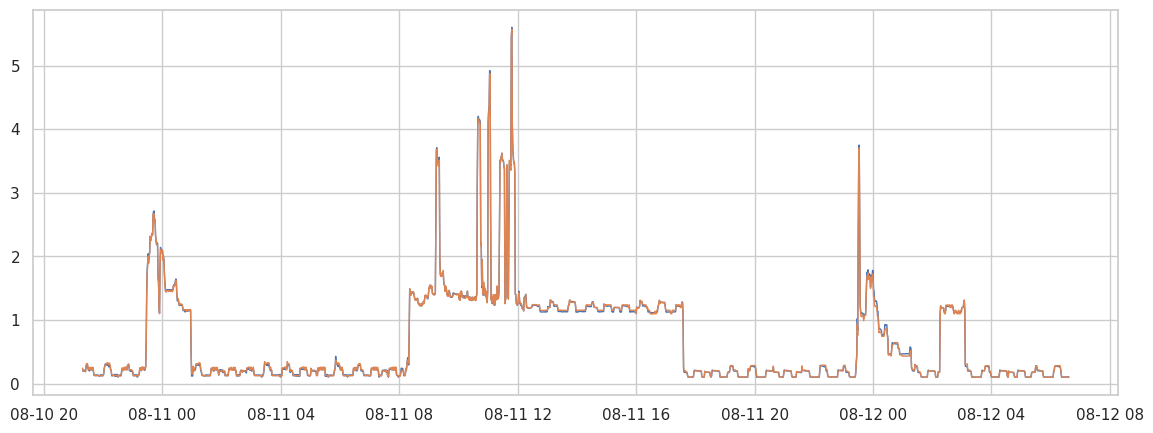

In [ ]:
# Plot a small slice of the test period so the lines remain readable.
plot_size = min(2_000, len(X_test))
test_slice = X_test.iloc[:plot_size]
actual_slice = y_test.iloc[:plot_size]
pred_slice = pd.Series(best_model.predict(test_slice), index=test_slice.index)

plt.figure(figsize=(14, 5))
plt.plot(actual_slice.index, actual_slice.values, label="Actual", linewidth=1)
plt.plot(pred_slice.index, pred_slice.values, label="Predicted", linewidth=1)
plt.title(f"Actual vs Predicted Power Usage ({best_model_name})")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

## 10. Feature Importance

NameError: name 'best_model_name' is not defined

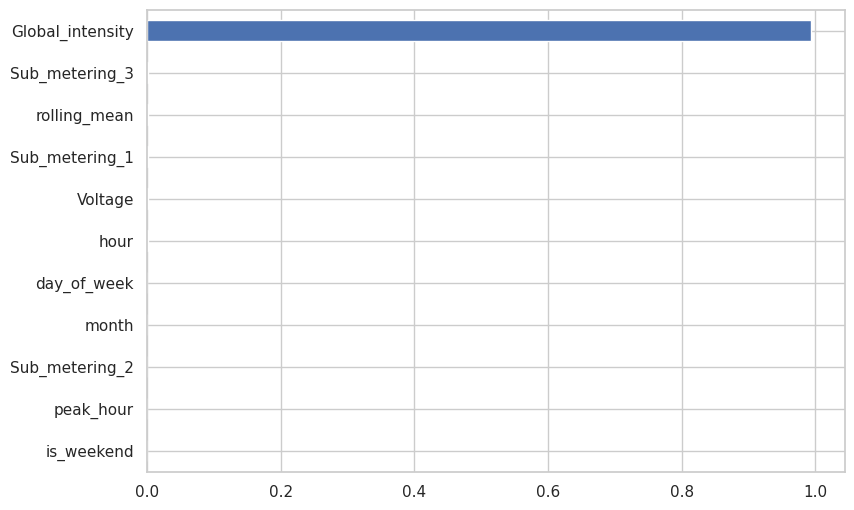

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
elif hasattr(best_model, "named_steps") and hasattr(best_model.named_steps["model"], "coef_"):
    importances = pd.Series(np.abs(best_model.named_steps["model"].coef_), index=feature_cols).sort_values()
else:
    importances = pd.Series(dtype=float)

plt.figure(figsize=(9, 6))
importances.plot(kind="barh")
plt.title(f"Feature Importance: {best_model_name}")
plt.xlabel("Importance")
plt.show()

## 11. Conclusion

The notebook uses a chronological split, lagged rolling features, and time-series cross-validation for tuning. The best model is selected by the lowest test RMSE, with MAE and R² reported for context. Leakage-prone derived features are kept out of training to make the evaluation realistic.